In [1]:
import os
import pydicom

image_folder = r"C:\Users\anudi\Downloads\MSc_Research\rsna-pneumonia-detection-challenge\stage_2_train_images"

sample_files = os.listdir(image_folder)[:20]

for file in sample_files:
    ds = pydicom.dcmread(os.path.join(image_folder, file))
    print(ds.pixel_array.shape)

(1024, 1024)
(1024, 1024)
(1024, 1024)
(1024, 1024)
(1024, 1024)
(1024, 1024)
(1024, 1024)
(1024, 1024)
(1024, 1024)
(1024, 1024)
(1024, 1024)
(1024, 1024)
(1024, 1024)
(1024, 1024)
(1024, 1024)
(1024, 1024)
(1024, 1024)
(1024, 1024)
(1024, 1024)
(1024, 1024)


In [3]:
import pandas as pd

class_info = pd.read_csv(
    r"C:\Users\anudi\Downloads\MSc_Research\rsna-pneumonia-detection-challenge\stage_2_detailed_class_info.csv"
)

print(class_info.head())

                              patientId                         class
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6  No Lung Opacity / Not Normal
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd  No Lung Opacity / Not Normal
2  00322d4d-1c29-4943-afc9-b6754be640eb  No Lung Opacity / Not Normal
3  003d8fa0-6bf1-40ed-b54c-ac657f8495c5                        Normal
4  00436515-870c-4b36-a041-de91049b9ab4                  Lung Opacity


In [4]:
binary_dataset = class_info[
    class_info["class"].isin(["Normal", "Lung Opacity"])
]

print(binary_dataset["class"].value_counts())

print("\nUnique Images:", binary_dataset["patientId"].nunique())

class
Lung Opacity    9555
Normal          8851
Name: count, dtype: int64

Unique Images: 14863


In [5]:
binary_dataset = binary_dataset.drop_duplicates(subset="patientId")

binary_dataset["label"] = binary_dataset["class"].map({
    "Normal": 0,
    "Lung Opacity": 1
})

print(binary_dataset["class"].value_counts())
print(binary_dataset.head())

class
Normal          8851
Lung Opacity    6012
Name: count, dtype: int64
                               patientId         class  label
3   003d8fa0-6bf1-40ed-b54c-ac657f8495c5        Normal      0
4   00436515-870c-4b36-a041-de91049b9ab4  Lung Opacity      1
8   00704310-78a8-4b38-8475-49f4573b2dbb  Lung Opacity      1
11  009482dc-3db5-48d4-8580-5c89c4f01334        Normal      0
12  009eb222-eabc-4150-8121-d5a6d06b8ebf        Normal      0


In [6]:
binary_dataset["class"] = binary_dataset["class"].replace({
    "Lung Opacity": "Pneumonia"
})

print(binary_dataset["class"].value_counts())
print(binary_dataset.head())

class
Normal       8851
Pneumonia    6012
Name: count, dtype: int64
                               patientId      class  label
3   003d8fa0-6bf1-40ed-b54c-ac657f8495c5     Normal      0
4   00436515-870c-4b36-a041-de91049b9ab4  Pneumonia      1
8   00704310-78a8-4b38-8475-49f4573b2dbb  Pneumonia      1
11  009482dc-3db5-48d4-8580-5c89c4f01334     Normal      0
12  009eb222-eabc-4150-8121-d5a6d06b8ebf     Normal      0


In [7]:
import os

output_path = r"C:\Users\anudi\Downloads\MSc_Research\processed_dataset"

os.makedirs(os.path.join(output_path, "Normal"), exist_ok=True)
os.makedirs(os.path.join(output_path, "Pneumonia"), exist_ok=True)

print("Folders created successfully")

Folders created successfully


Original shape: (1024, 1024)
Resized shape: (224, 224)
Class: Normal


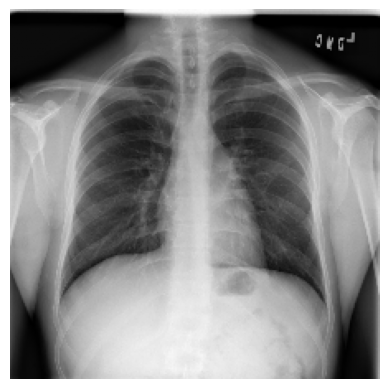

In [8]:
import os
import pydicom
import cv2
import matplotlib.pyplot as plt

input_path = r"C:\Users\anudi\Downloads\MSc_Research\rsna-pneumonia-detection-challenge\stage_2_train_images"
output_path = r"C:\Users\anudi\Downloads\MSc_Research\processed_dataset"

sample = binary_dataset.iloc[0]
patient_id = sample["patientId"]
class_name = sample["class"]

dcm_path = os.path.join(input_path, patient_id + ".dcm")

ds = pydicom.dcmread(dcm_path)
image = ds.pixel_array

resized_image = cv2.resize(image, (224, 224))

print("Original shape:", image.shape)
print("Resized shape:", resized_image.shape)
print("Class:", class_name)

plt.imshow(resized_image, cmap="gray")
plt.axis("off")
plt.show()

(224, 224, 3)


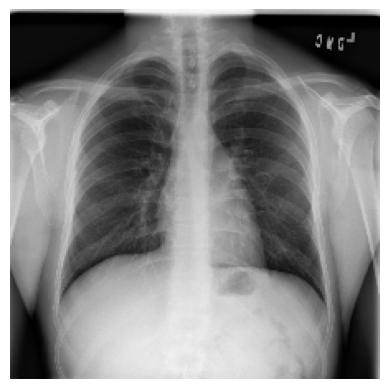

In [9]:
import cv2
import matplotlib.pyplot as plt

rgb_image = cv2.cvtColor(resized_image, cv2.COLOR_GRAY2RGB)

print(rgb_image.shape)

plt.imshow(rgb_image)
plt.axis("off")
plt.show()

In [10]:
print(binary_dataset["class"].value_counts())

class
Normal       8851
Pneumonia    6012
Name: count, dtype: int64


In [11]:
print(binary_dataset.head())
print(binary_dataset.tail())

                               patientId      class  label
3   003d8fa0-6bf1-40ed-b54c-ac657f8495c5     Normal      0
4   00436515-870c-4b36-a041-de91049b9ab4  Pneumonia      1
8   00704310-78a8-4b38-8475-49f4573b2dbb  Pneumonia      1
11  009482dc-3db5-48d4-8580-5c89c4f01334     Normal      0
12  009eb222-eabc-4150-8121-d5a6d06b8ebf     Normal      0
                                  patientId      class  label
30219  c1e73a4e-7afe-4ec5-8af6-ce8315d7a2f2  Pneumonia      1
30221  c1ec14ff-f6d7-4b38-b0cb-fe07041cbdc8  Pneumonia      1
30223  c1edf42b-5958-47ff-a1e7-4f23d99583ba     Normal      0
30224  c1f6b555-2eb1-4231-98f6-50a963976431     Normal      0
30225  c1f7889a-9ea9-4acb-b64c-b737c929599a  Pneumonia      1


In [12]:
print(binary_dataset["class"].unique())

['Normal' 'Pneumonia']


In [13]:
import cv2
import os

sample = binary_dataset.iloc[0]

patient_id = sample["patientId"]
class_name = sample["class"]

save_path = os.path.join(
    output_path,
    class_name,
    patient_id + ".png"
)

cv2.imwrite(save_path, rgb_image)

print("Saved:", save_path)

Saved: C:\Users\anudi\Downloads\MSc_Research\processed_dataset\Normal\003d8fa0-6bf1-40ed-b54c-ac657f8495c5.png


In [16]:
import os
import cv2
import pydicom
import numpy as np

input_path = r"C:\Users\anudi\Downloads\MSc_Research\rsna-pneumonia-detection-challenge\stage_2_train_images"

output_path = r"C:\Users\anudi\Downloads\MSc_Research\processed_dataset"

total = len(binary_dataset)

for index, row in binary_dataset.iterrows():

    if index % 500 == 0:
        print(f"Processed {index}/{total} images")

    patient_id = row["patientId"]
    class_name = row["class"]

    dcm_path = os.path.join(
        input_path,
        patient_id + ".dcm"
    )

    save_path = os.path.join(
        output_path,
        class_name,
        patient_id + ".png"
    )

    try:
        ds = pydicom.dcmread(dcm_path)

        image = ds.pixel_array

        image = cv2.resize(image, (224, 224))

        image = cv2.normalize(
            image,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        )

        image = image.astype(np.uint8)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_GRAY2RGB
        )

        cv2.imwrite(save_path, image)

    except Exception as e:
        print(f"Error processing {patient_id}: {e}")

print("Dataset preprocessing completed.")

Processed 1000/14863 images
Processed 3000/14863 images
Processed 5000/14863 images
Processed 6000/14863 images
Processed 7500/14863 images
Processed 8000/14863 images
Processed 10000/14863 images
Processed 11500/14863 images
Processed 12000/14863 images
Processed 14000/14863 images
Processed 14500/14863 images
Processed 15000/14863 images
Processed 15500/14863 images
Processed 17000/14863 images
Processed 17500/14863 images
Processed 18500/14863 images
Processed 19000/14863 images
Processed 19500/14863 images
Processed 20500/14863 images
Processed 21000/14863 images
Processed 21500/14863 images
Processed 22500/14863 images
Processed 23000/14863 images
Processed 24500/14863 images
Processed 25000/14863 images
Processed 26000/14863 images
Processed 26500/14863 images
Processed 28500/14863 images
Processed 29000/14863 images
Processed 29500/14863 images
Processed 30000/14863 images
Dataset preprocessing completed.


In [17]:
import os

normal_count = len(os.listdir(
    r"C:\Users\anudi\Downloads\MSc_Research\processed_dataset\Normal"
))

pneumonia_count = len(os.listdir(
    r"C:\Users\anudi\Downloads\MSc_Research\processed_dataset\Pneumonia"
))

print("Normal:", normal_count)
print("Pneumonia:", pneumonia_count)
print("Total:", normal_count + pneumonia_count)

Normal: 8851
Pneumonia: 6012
Total: 14863


In [18]:
print(len(binary_dataset))
print(binary_dataset["patientId"].nunique())

14863
14863


In [19]:
import os
import shutil
from sklearn.model_selection import train_test_split

source_path = r"C:\Users\anudi\Downloads\MSc_Research\processed_dataset"
final_path = r"C:\Users\anudi\Downloads\MSc_Research\final_dataset"

classes = ["Normal", "Pneumonia"]

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(final_path, split, cls), exist_ok=True)

for cls in classes:
    class_folder = os.path.join(source_path, cls)
    images = os.listdir(class_folder)

    train_files, temp_files = train_test_split(
        images, test_size=0.30, random_state=42
    )

    val_files, test_files = train_test_split(
        temp_files, test_size=0.50, random_state=42
    )

    for file in train_files:
        shutil.copy(
            os.path.join(class_folder, file),
            os.path.join(final_path, "train", cls, file)
        )

    for file in val_files:
        shutil.copy(
            os.path.join(class_folder, file),
            os.path.join(final_path, "val", cls, file)
        )

    for file in test_files:
        shutil.copy(
            os.path.join(class_folder, file),
            os.path.join(final_path, "test", cls, file)
        )

print("Train/Validation/Test split completed.")

C:\Python311\Lib\site-packages\sklearn\utils\__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.sparse import issparse


Train/Validation/Test split completed.


In [20]:
import os

base = r"C:\Users\anudi\Downloads\MSc_Research\final_dataset"

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")

    for cls in ["Normal", "Pneumonia"]:
        count = len(os.listdir(os.path.join(base, split, cls)))
        print(cls, count)


TRAIN
Normal 6195
Pneumonia 4208

VAL
Normal 1328
Pneumonia 902

TEST
Normal 1328
Pneumonia 902
